<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/AVCAD-EXERCISE/blob/main/Exercise8_Regression_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [15]:
# Load dataset

df = pd.read_csv(
    "EFIplus_medit.csv",
    sep=';'
)

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [16]:
print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [17]:
# Find species columns

species_start = df.columns.get_loc(
    'Abramis brama'
)

species_columns = df.columns[
    species_start:
]

# Species richness

df['species_richness'] = df[
    species_columns
].sum(axis=1)

# Preview

df['species_richness'].head()

,species_richness
0,1
1,1
2,1
3,2
4,2


In [18]:
# Predictor variables

variables = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

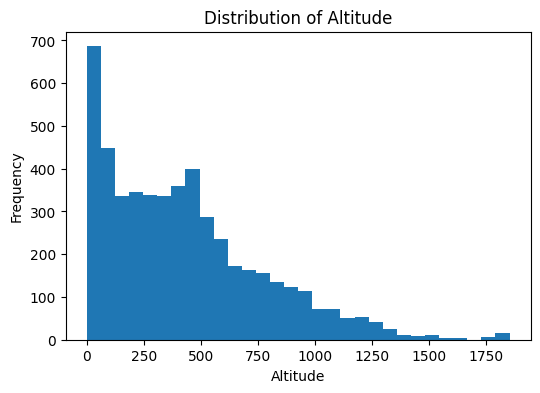

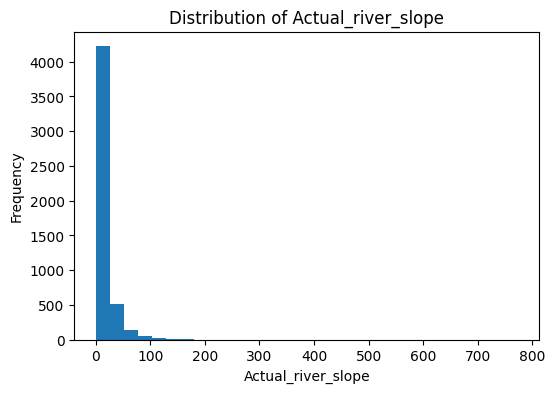

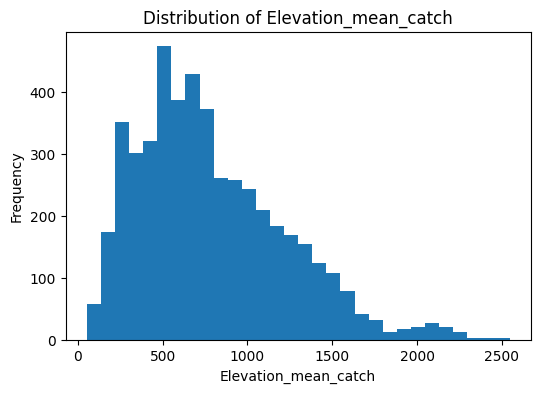

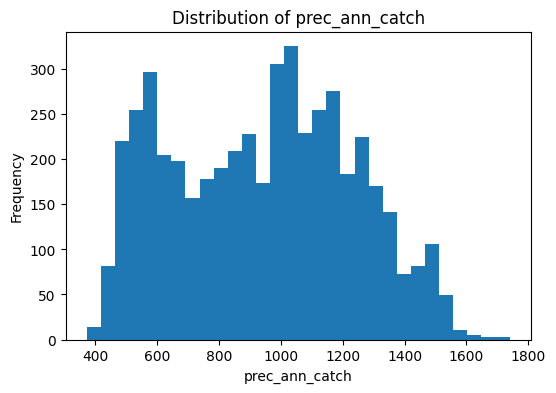

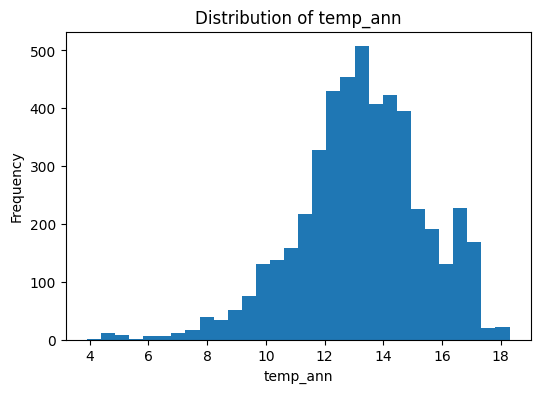

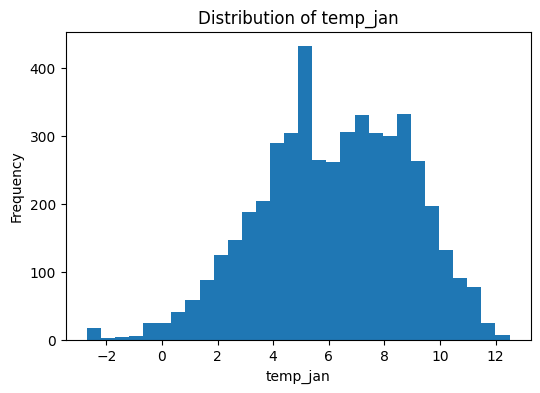

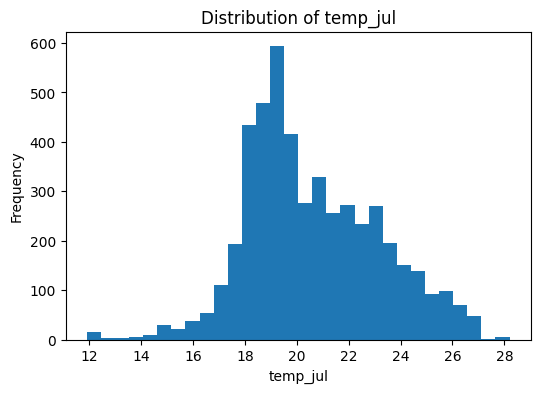

In [19]:
# Histograms

for var in variables:

    plt.figure(figsize=(6,4))

    plt.hist(
        pd.to_numeric(df[var], errors='coerce').dropna(),
        bins=30
    )

    plt.title(f"Distribution of {var}")

    plt.xlabel(var)
    plt.ylabel("Frequency")

    plt.show()

In [20]:
# Log transformations

df['log_Altitude'] = np.log1p(
    df['Altitude']
)

df['log_prec_ann_catch'] = np.log1p(
    df['prec_ann_catch']
)

df[['log_Altitude', 'log_prec_ann_catch']].head()

,log_Altitude,log_prec_ann_catch
0,5.298317,6.259718
1,7.134094,6.463541
2,7.052721,6.452426
3,6.980076,6.440694
4,6.926577,6.434725


In [21]:
# Function for simple regression

def run_regression(x_var):

    temp_df = df[
        [x_var, 'species_richness']
    ].dropna()

    X = sm.add_constant(
        temp_df[x_var]
    )

    y = temp_df['species_richness']

    model = sm.OLS(y, X).fit()

    print(f"\nRegression using {x_var}")
    print(model.summary())

    # Plot

    sns.regplot(
        x=temp_df[x_var],
        y=y,
        line_kws={'color':'red'}
    )

    plt.title(
        f"Species Richness vs {x_var}"
    )

    plt.show()


Regression using log_Altitude
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     629.7
Date:                Mon, 25 May 2026   Prob (F-statistic):          5.42e-131
Time:                        13:15:32   Log-Likelihood:                -12112.
No. Observations:                5011   AIC:                         2.423e+04
Df Residuals:                    5009   BIC:                         2.424e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            

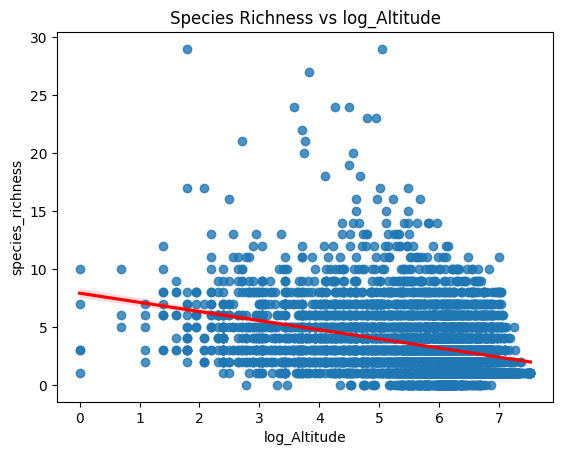


Regression using Actual_river_slope
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     302.6
Date:                Mon, 25 May 2026   Prob (F-statistic):           7.80e-66
Time:                        13:15:33   Log-Likelihood:                -12175.
No. Observations:                4975   AIC:                         2.435e+04
Df Residuals:                    4973   BIC:                         2.437e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

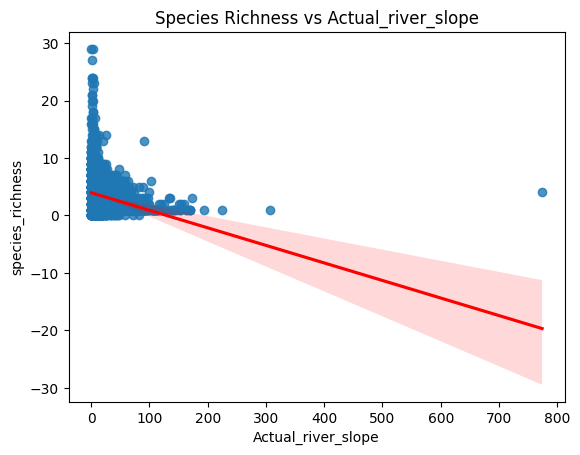


Regression using Elevation_mean_catch
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     281.7
Date:                Mon, 25 May 2026   Prob (F-statistic):           1.71e-61
Time:                        13:15:33   Log-Likelihood:                -11808.
No. Observations:                4841   AIC:                         2.362e+04
Df Residuals:                    4839   BIC:                         2.363e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

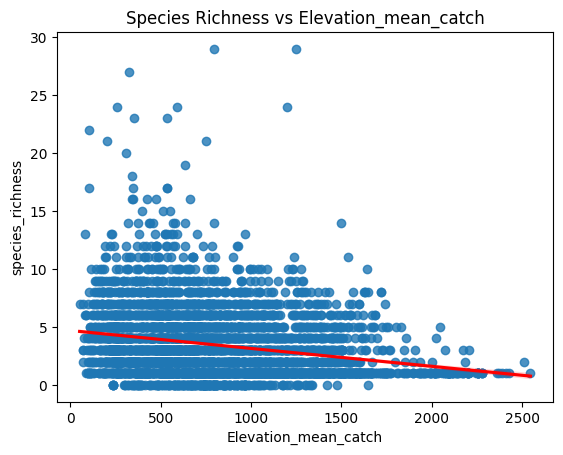


Regression using log_prec_ann_catch
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     97.56
Date:                Mon, 25 May 2026   Prob (F-statistic):           8.55e-23
Time:                        13:15:34   Log-Likelihood:                -11897.
No. Observations:                4841   AIC:                         2.380e+04
Df Residuals:                    4839   BIC:                         2.381e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

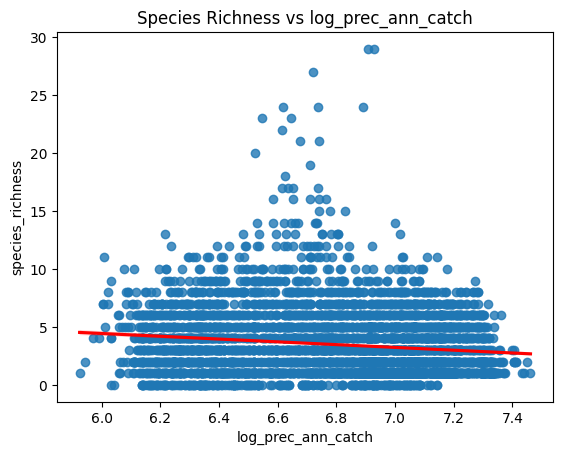


Regression using temp_ann
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     510.9
Date:                Mon, 25 May 2026   Prob (F-statistic):          1.27e-107
Time:                        13:15:34   Log-Likelihood:                -11702.
No. Observations:                4841   AIC:                         2.341e+04
Df Residuals:                    4839   BIC:                         2.342e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9130    

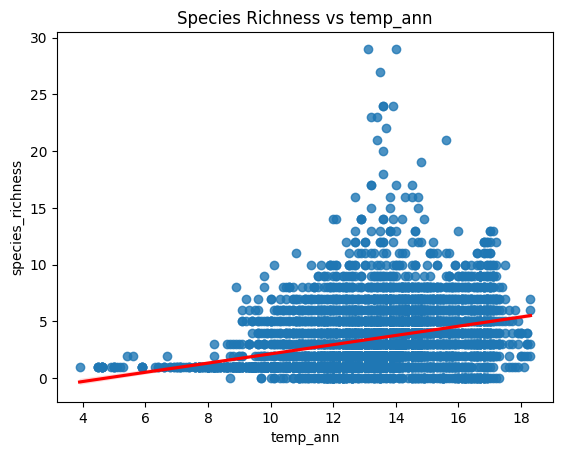


Regression using temp_jan
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     211.2
Date:                Mon, 25 May 2026   Prob (F-statistic):           7.36e-47
Time:                        13:15:35   Log-Likelihood:                -11842.
No. Observations:                4841   AIC:                         2.369e+04
Df Residuals:                    4839   BIC:                         2.370e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1093    

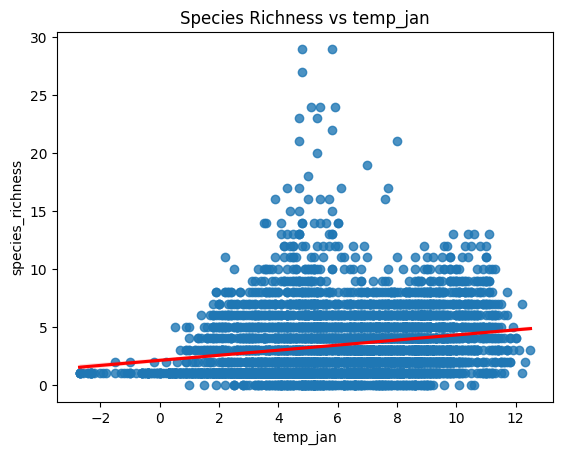


Regression using temp_jul
                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     496.4
Date:                Mon, 25 May 2026   Prob (F-statistic):          8.95e-105
Time:                        13:15:36   Log-Likelihood:                -11709.
No. Observations:                4841   AIC:                         2.342e+04
Df Residuals:                    4839   BIC:                         2.343e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4728    

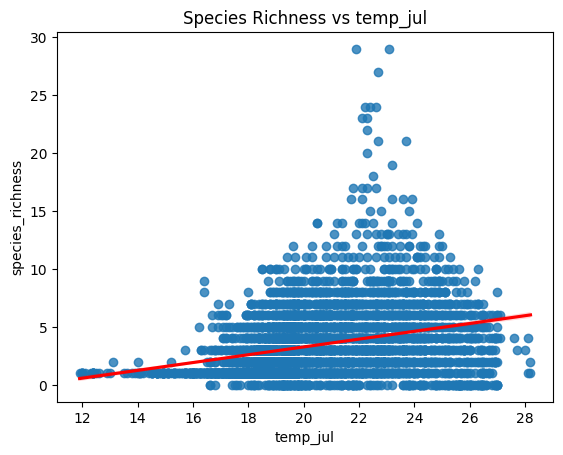

In [22]:
# Run regressions

regression_vars = [
    'log_Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'log_prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

for var in regression_vars:

    run_regression(var)

# Exercise 1 Interpretation

Simple linear regressions were used to evaluate the relationship between species richness and environmental variables.

The regression summaries provide:
- coefficient estimates
- R-squared values
- F-statistics
- significance tests

The fitted regression plots visualize the direction and strength of the relationships.

In [23]:
# Multiple regression variables

multi_vars = [
    'log_Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'log_prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

multi_df = df[
    multi_vars + ['species_richness']
].dropna()

multi_df.head()

,log_Altitude,Actual_river_slope,Elevation_mean_catch,log_prec_ann_catch,temp_ann,temp_jan,temp_jul,species_richness
0,5.298317,0.001,700.840807,6.259718,17.6,8.5,28.1,1
1,7.134094,13.406,1603.519424,6.463541,9.3,0.6,18.9,1
2,7.052721,9.398,1578.678579,6.452426,10.1,1.2,19.6,1
3,6.980076,8.186,1553.219128,6.440694,10.1,1.2,19.5,2
4,6.926577,11.736,1539.684999,6.434725,10.3,1.7,20.0,2


In [24]:
# Multiple regression

X = sm.add_constant(
    multi_df[multi_vars]
)

y = multi_df['species_richness']

multi_model = sm.OLS(y, X).fit()

print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     204.3
Date:                Mon, 25 May 2026   Prob (F-statistic):          2.84e-266
Time:                        13:15:36   Log-Likelihood:                -11268.
No. Observations:                4819   AIC:                         2.255e+04
Df Residuals:                    4811   BIC:                         2.260e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -1.6782 

# Exercise 2 Interpretation

Multiple linear regression evaluates the combined effects of environmental variables on species richness.

The coefficients may differ from the simple regressions because the predictors are evaluated simultaneously while controlling for the effects of the other variables.

In [25]:
# VIF calculation

vif_data = pd.DataFrame()

vif_data['Variable'] = multi_vars

vif_data['VIF'] = [

    variance_inflation_factor(
        multi_df[multi_vars].values,
        i
    )

    for i in range(len(multi_vars))
]

print(vif_data)

               Variable          VIF
0          log_Altitude    67.324778
1    Actual_river_slope     1.593692
2  Elevation_mean_catch    17.977216
3    log_prec_ann_catch   141.368038
4              temp_ann  2195.617874
5              temp_jan   172.763067
6              temp_jul  1161.615492


In [26]:
# Reduced variable set

reduced_vars = [
    'log_Altitude',
    'log_prec_ann_catch',
    'temp_ann'
]

reduced_df = df[
    reduced_vars + ['species_richness']
].dropna()

# Regression

X = sm.add_constant(
    reduced_df[reduced_vars]
)

y = reduced_df['species_richness']

reduced_model = sm.OLS(y, X).fit()

print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     251.8
Date:                Mon, 25 May 2026   Prob (F-statistic):          7.52e-152
Time:                        13:15:37   Log-Likelihood:                -11594.
No. Observations:                4841   AIC:                         2.320e+04
Df Residuals:                    4837   BIC:                         2.322e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 14.9214      1

# Exercise 3 Interpretation

Variance Inflation Factors (VIFs) were used to assess multicollinearity among predictors.

A reduced parsimonious model was created by removing highly correlated variables.

The regression coefficients changed because multicollinearity influences coefficient estimation.

# Final Conclusion

This exercise demonstrated:
- simple linear regression
- multiple regression
- multicollinearity analysis
- parsimonious model selection

Environmental variables showed varying relationships with species richness.